In [52]:
import pandas as pd
import numpy as np
import math

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as GridSpec
import warnings

from itertools import combinations
from collections import Counter


from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer

from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler


from functions import * 

from scipy.stats import skew
from sklearn.cluster import DBSCAN
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from sklearn.metrics import pairwise_distances
from sklearn.cluster import AgglomerativeClustering

#!pip install minisom --upgrade
from minisom import MiniSom
from matplotlib.patches import RegularPolygon, Ellipse
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib import cm, colorbar
from matplotlib import colors as mpl_colors
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.cluster import MeanShift, DBSCAN, estimate_bandwidth
from sklearn.metrics import silhouette_score, silhouette_samples
from matplotlib import cm
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import NearestNeighbors
from numpy.linalg import eig



In [53]:
df = pd.read_csv("PREPROCESSED_DATASET.csv")

In [54]:
df.columns

Index(['customer_id', 'customer_age', 'vendor_count', 'product_count',
       'is_chain', 'first_order', 'last_order', 'CUI_American', 'CUI_Asian',
       'CUI_Beverages',
       ...
       'last_promo_DELIVERY', 'last_promo_DISCOUNT', 'last_promo_FREEBIE',
       'last_promo_NO PROMO', 'payment_method_CARD', 'payment_method_CASH',
       'payment_method_DIGI', 'customer_activity_Active',
       'customer_activity_Churning', 'customer_activity_Recent'],
      dtype='object', length=115)

# Features selected for Preference

In [55]:
selected_features_percent = ["Asian_Street_percent", "Other_Chinese_percent", "Italian_American_percent", "AM_preference_percent"]

preferences_cols = selected_features_percent


# Hierarchical Clustering

C:\Users\gaspa\AppData\Local\Temp\ipykernel_30044\1906437299.py:12: UserWarning: The markers list has more values (4) than needed (2), which may not be intended.
  sns.lineplot(data=r2_hc_methods, linewidth=2.5, markers=["o"]*4)


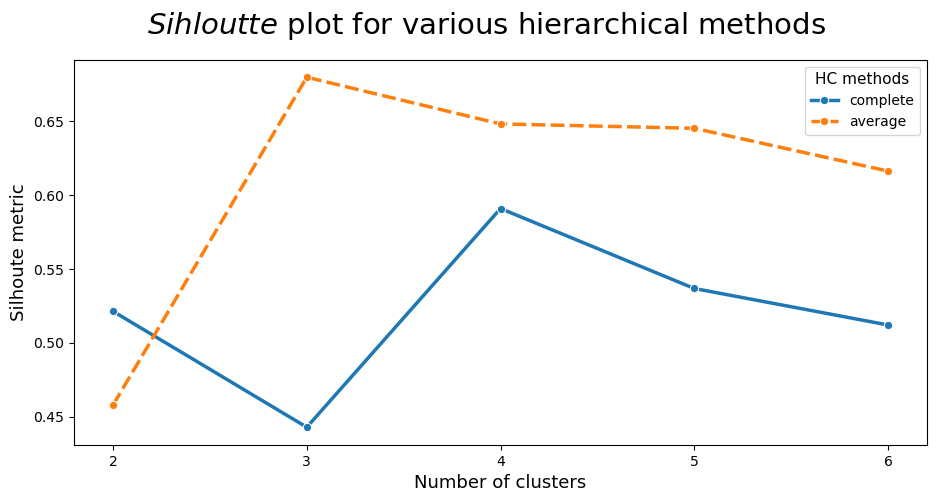

In [56]:

hc_methods = ["complete", "average"] # ward doesnt work with cosine distances / single always bad
max_nclus = 6
r2_hc = np.vstack([ get_silhouette_hc(df[preferences_cols], 
                              link, 
                              max_nclus=max_nclus, 
                              min_nclus=2, 
                              dist="cosine") 
                              for link in hc_methods])

r2_hc_methods = pd.DataFrame(r2_hc.T, index=range(2, max_nclus + 1), columns=hc_methods)
fig = plt.figure(figsize=(11,5))
sns.lineplot(data=r2_hc_methods, linewidth=2.5, markers=["o"]*4)
plt.legend(title="HC methods", title_fontsize=11)
plt.xticks(range(2, max_nclus + 1))
plt.xlabel("Number of clusters", fontsize=13)
plt.ylabel("Silhoute metric", fontsize=13)
fig.suptitle("$Sihloutte$ plot for various hierarchical methods", fontsize=21)
plt.show()


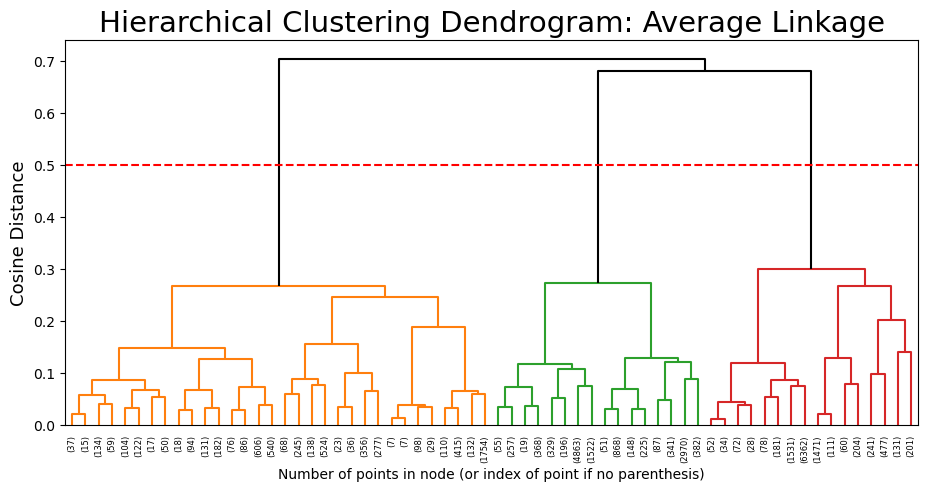

In [57]:

link = 'average'
distance = 'cosine'
hclust = AgglomerativeClustering(linkage=link, metric=distance, distance_threshold=0, n_clusters=None)
hclust.fit_predict(df[preferences_cols])

counts = np.zeros(hclust.children_.shape[0])
n_samples = len(hclust.labels_)
for i, merge in enumerate(hclust.children_):
    current_count = 0
    for child_idx in merge:
        if child_idx < n_samples:
            current_count += 1 
        else:
            current_count += counts[child_idx - n_samples]
    counts[i] = current_count
linkage_matrix = np.column_stack([hclust.children_, hclust.distances_, counts]).astype(float)

fig = plt.figure(figsize=(11,5))
y_threshold = 0.5
dendrogram(linkage_matrix, truncate_mode='level', p=5, color_threshold=y_threshold, above_threshold_color='k')
plt.hlines(y_threshold, 0, 1000, colors="r", linestyles="dashed")
plt.title(f'Hierarchical Clustering Dendrogram: {link.title()} Linkage', fontsize=21)
plt.xlabel('Number of points in node (or index of point if no parenthesis)')
plt.ylabel(f'{distance.title()} Distance', fontsize=13)
plt.show()




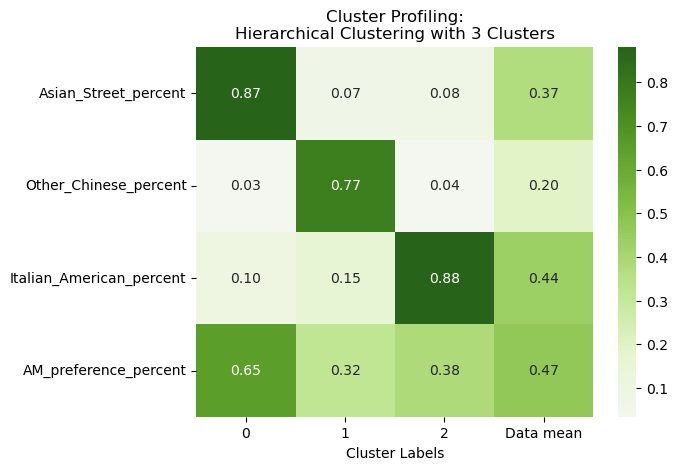

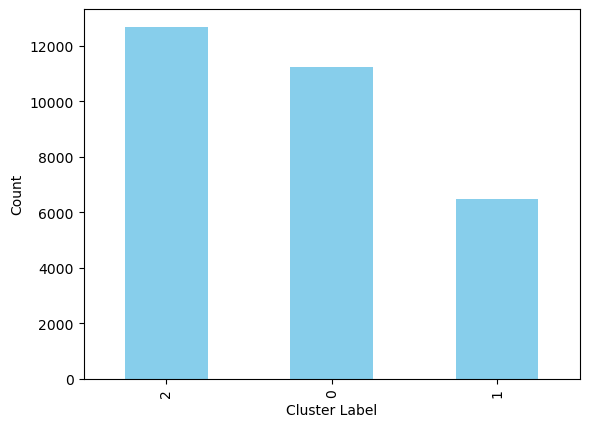

In [58]:


hc_clust = AgglomerativeClustering(n_clusters=3, linkage="average", metric="cosine")
hc_labels = hc_clust.fit_predict(df[preferences_cols])


df_concat = pd.concat((df[preferences_cols], pd.Series(hc_labels, name='labels', index=df.index)), axis=1)

cluster_means = df_concat.groupby('labels')[preferences_cols].mean().T
overall_means = df[preferences_cols].mean()
overall_means.name = "Data mean"

cluster_means = pd.concat((cluster_means, overall_means), axis=1)
# df_concat = pd.concat((df_concat.T, df_means), axis=1)
# r2 = get_rsq(df_concat, preferences_cols, 'labels')

sns.heatmap(cluster_means, center=0, annot=True, cmap="PiYG", fmt=".2f")
plt.xlabel("Cluster Labels")
plt.title("Cluster Profiling:\nHierarchical Clustering with 3 Clusters")
plt.show()


df_concat['labels'].value_counts().plot(kind='bar', color='skyblue')
plt.xlabel('Cluster Label')
plt.ylabel('Count')
plt.show()

In [59]:
silhouettes_avgs = []
silho = silhouette_score(df[preferences_cols], hc_labels, metric='cosine')
silhouettes_avgs.append(silho)
silho

0.6794453652602869

# KMeans Clustering 

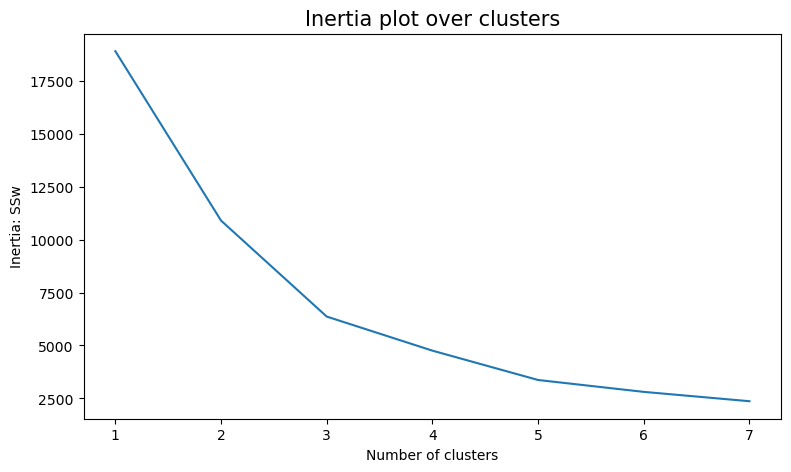

In [60]:

range_clusters = range(1, 8)
inertia = []
for n_clus in range_clusters:  
    kmclust = KMeans(n_clusters=n_clus, init='k-means++', n_init=15, random_state=42)
    kmclust.fit(df[preferences_cols])
    inertia.append(kmclust.inertia_)
    
fig, ax = plt.subplots(figsize=(9,5))
ax.plot(range_clusters, inertia)
ax.set_xticks(range_clusters)
ax.set_ylabel("Inertia: SSw")
ax.set_xlabel("Number of clusters")
ax.set_title("Inertia plot over clusters", size=15)
plt.show()


For n_clusters = 2, the average silhouette_score is : 0.533317284437143
For n_clusters = 3, the average silhouette_score is : 0.7030190108470945
For n_clusters = 4, the average silhouette_score is : 0.6449311947866948
For n_clusters = 5, the average silhouette_score is : 0.624497399143215
For n_clusters = 6, the average silhouette_score is : 0.6089715649410746
For n_clusters = 7, the average silhouette_score is : 0.5980096249036736


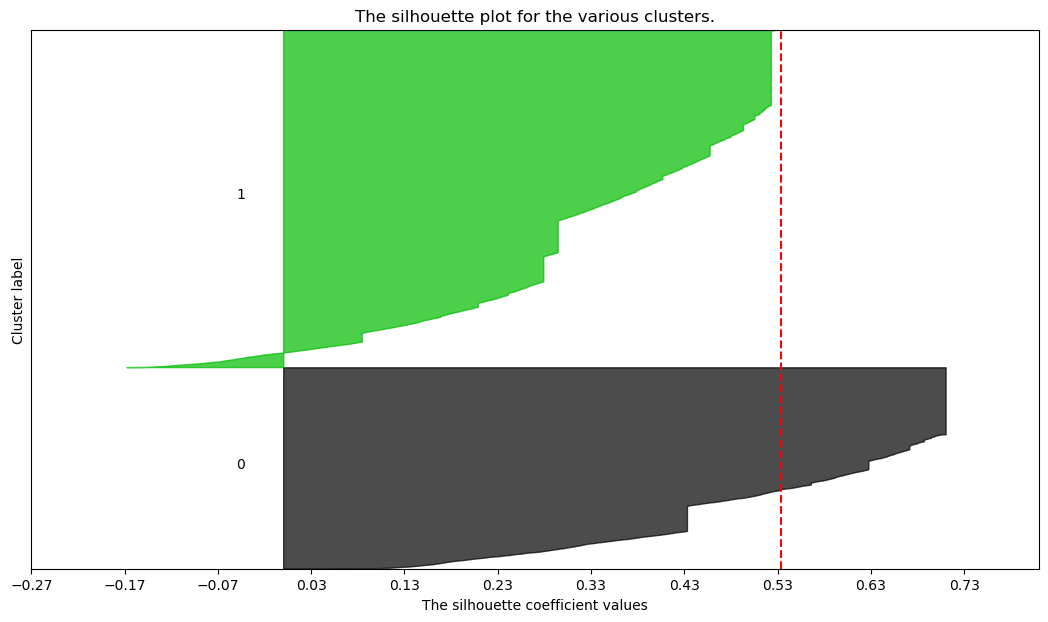

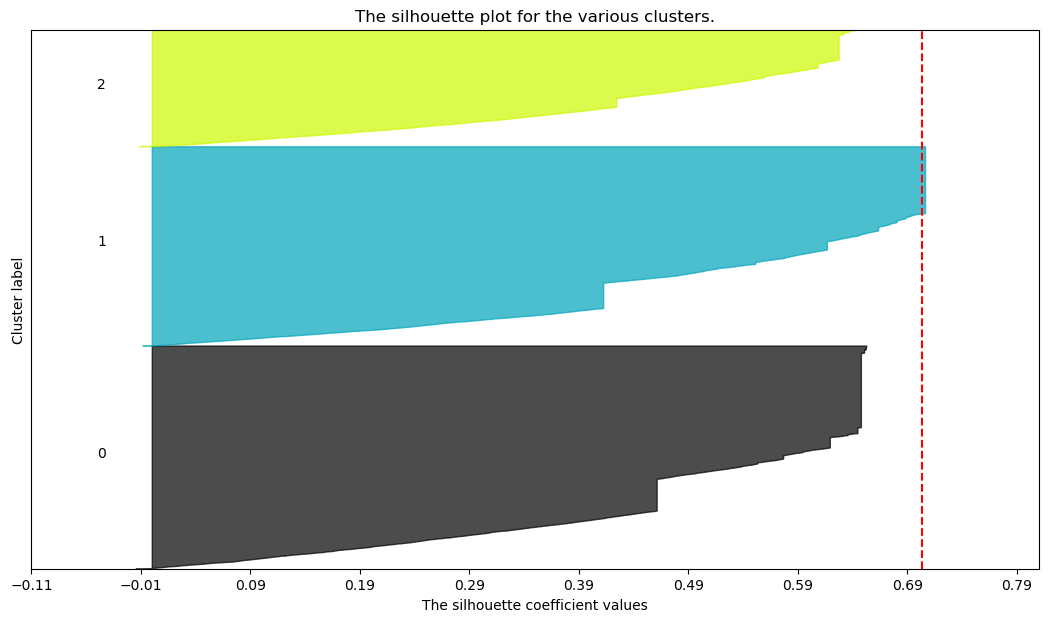

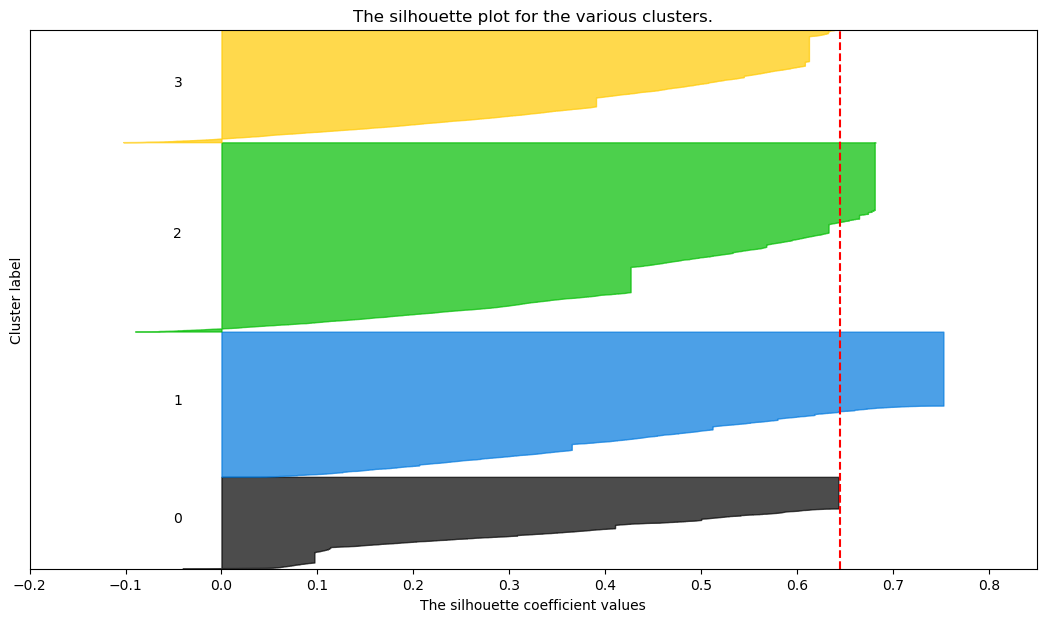

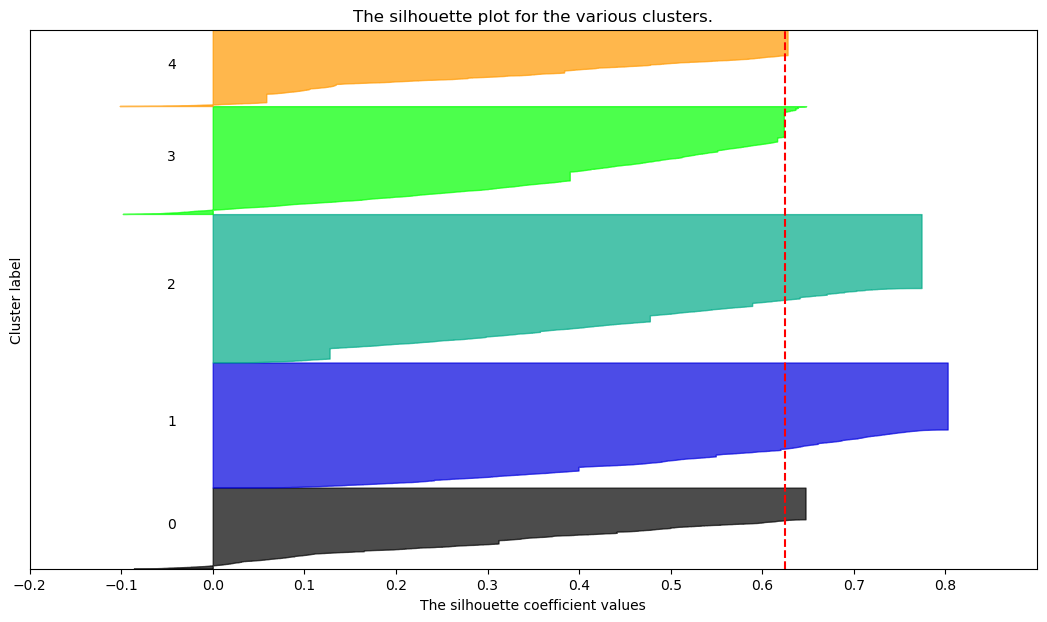

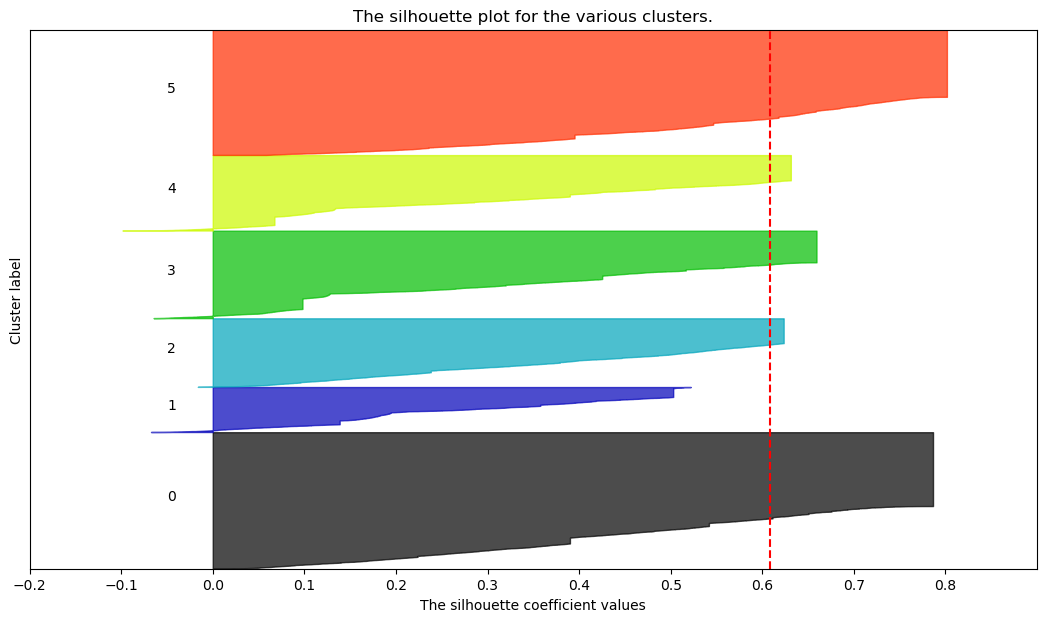

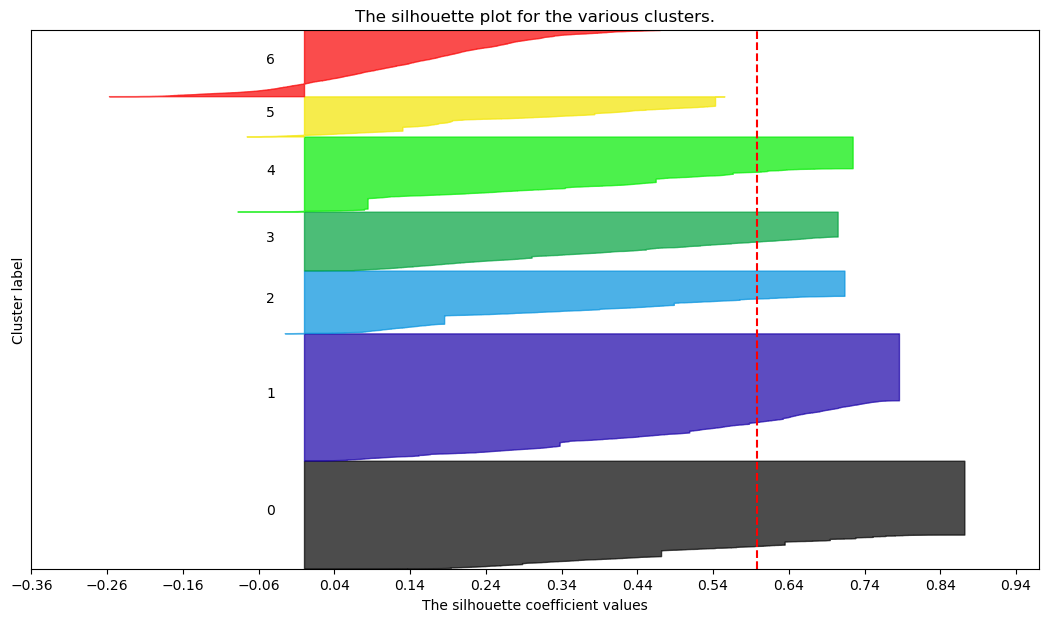

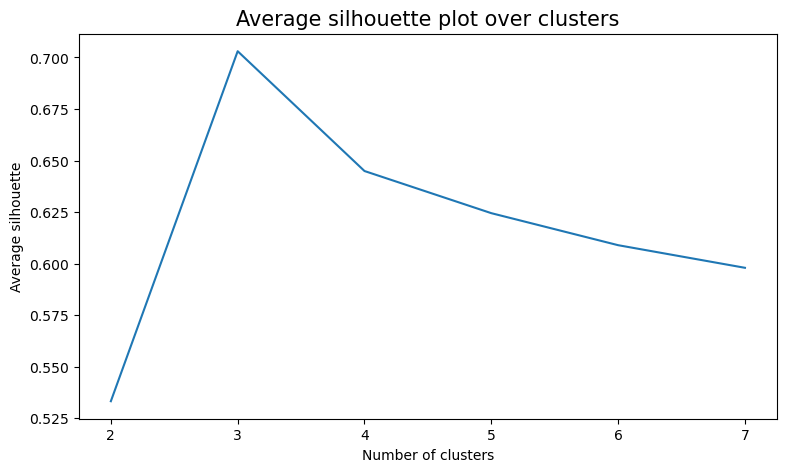

In [61]:

avg_silhouette = []
for nclus in range_clusters:
    if nclus == 1:
        continue
    
    fig = plt.figure(figsize=(13, 7))

    kmclust = KMeans(n_clusters=nclus, init='k-means++', n_init=15, random_state=42)
    cluster_labels = kmclust.fit_predict(df[preferences_cols])

    silhouette_avg = silhouette_score(df[preferences_cols], cluster_labels, metric='cosine')
    avg_silhouette.append(silhouette_avg)
    print(f"For n_clusters = {nclus}, the average silhouette_score is : {silhouette_avg}")

    sample_silhouette_values = silhouette_samples(df[preferences_cols], cluster_labels)

    y_lower = 10
    for i in range(nclus):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()
        
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        
        color = cm.nipy_spectral(float(i) / nclus)
        plt.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        y_lower = y_upper + 10  

    plt.title("The silhouette plot for the various clusters.")
    plt.xlabel("The silhouette coefficient values")
    plt.ylabel("Cluster label")

    plt.axvline(x=silhouette_avg, color="red", linestyle="--")
    
    xmin, xmax = np.round(sample_silhouette_values.min() -0.1, 2), np.round(sample_silhouette_values.max() + 0.1, 2)
    plt.xlim([xmin, xmax])

    plt.ylim([0, len(df[preferences_cols]) + (nclus + 1) * 10])

    plt.yticks([])  
    plt.xticks(np.arange(xmin, xmax, 0.1))
    

plt.figure(figsize=(9,5))
plt.plot(range_clusters[1:], 
         avg_silhouette)
plt.ylabel("Average silhouette")
plt.xlabel("Number of clusters")
plt.title("Average silhouette plot over clusters", size=15)
plt.show()



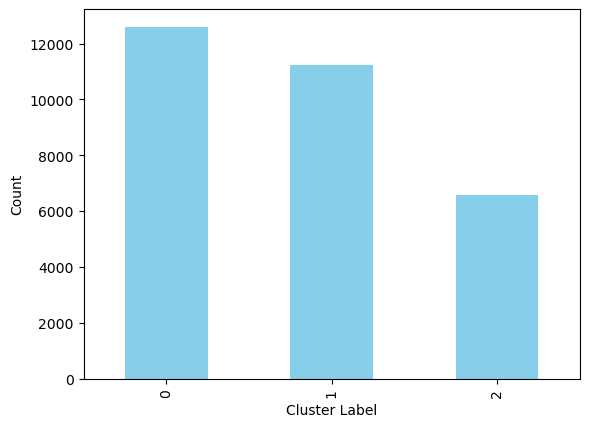

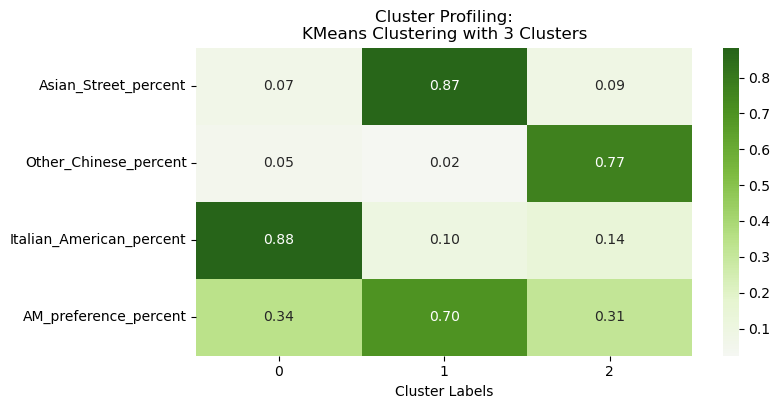

In [62]:

number_clusters = 3
kmclust = KMeans(n_clusters=3, init='k-means++', n_init=15, random_state=42)
km_labels = kmclust.fit_predict(df[preferences_cols])


normalized_df = pd.DataFrame(df[preferences_cols], columns=preferences_cols, index=df.index)

df_concat = pd.concat((normalized_df, pd.Series(km_labels, name='labels', index=df.index)), axis=1)

#r2 = get_rsq(df_concat, preferences_cols, 'labels')

df_concat['labels'].value_counts().plot(kind='bar', color='skyblue')
plt.xlabel('Cluster Label')
plt.ylabel('Count')
plt.show()

fig, ax = plt.subplots(figsize=(8,4))
km_profile = df_concat.groupby('labels').mean().T
sns.heatmap(km_profile,
            center=0, annot=True, cmap="PiYG", fmt=".2f",
            ax=ax)
ax.set_xlabel("Cluster Labels")
ax.set_title("Cluster Profiling:\nKMeans Clustering with 3 Clusters")
plt.show()



In [63]:
silho = silhouette_score(normalized_df, km_labels, metric='cosine')
silhouettes_avgs.append(silho)
silho

0.7030190108470945

<Axes: xlabel='Hierarchical Clustering'>

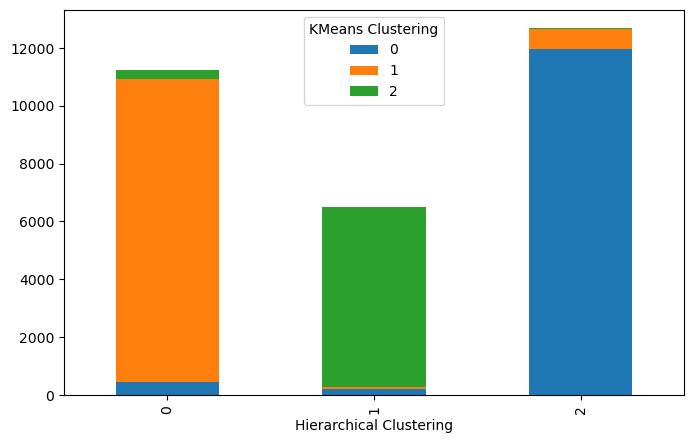

In [64]:
pd.crosstab(
    pd.Series(hc_labels, name="Hierarchical Clustering"),
    pd.Series(km_labels, name="KMeans Clustering")
).plot(kind="bar", figsize=(8, 5), stacked=True)

# SOM Clustering (Emergent SOM)

In [65]:

neigh = 'gaussian'
topol = 'hexagonal'
n_feats = len(preferences_cols)
activation_distc = 'cosine'

som_data = df[preferences_cols].values


In [66]:

# based on "ESOM-Maps: tools for clustering, visualization, and classification with Emergent SOM" 
from numpy.linalg import eig


cov_matrix = np.cov(df[preferences_cols].T)

eigenvalues, _ = eig(cov_matrix)
eigenvalues = sorted(eigenvalues.round(3), reverse=True)
ratio = eigenvalues[0] / eigenvalues[1]
ratio.round(2)


1.84

In [67]:
grid_size = 4_000 
M = np.sqrt(grid_size * ratio).round().astype(int)
N = (grid_size / M).round().astype(int)
print(f"M: {M}, N: {N}")

M: 86, N: 47


In [68]:

neigh = 'gaussian'
topol = 'hexagonal'
n_feats = len(preferences_cols)

#map_size = [(29, 29), (50, 50)]
learning_rates = [0.5] # 0.3, 0.6 
sigmas = [3] # 1, 1.5, 2, 2.5
epochs_list = [500_000]

som_data = df[preferences_cols].values

best_te = float('inf')
best_params = {}

for lr in learning_rates:
    for sigma in sigmas:
        sm = MiniSom(M, N, n_feats, sigma=sigma, learning_rate=lr, neighborhood_function=neigh, topology=topol, random_seed=42, activation_distance=activation_distc)
        sm.random_weights_init(som_data)

        sm.train_batch(som_data, epochs_list[0])

        qe = sm.quantization_error(som_data)
        te = sm.topographic_error(som_data)

        print(f"LR: {lr}, Sigma: {sigma}, Epochs: {epochs_list[0]} -> QE: {qe:.3f}, TE: {te:.3f}")

        # Update best parameters based on TE
        if te < best_te:
            best_te = te
            best_params = {'learning_rate': lr, 'sigma': sigma, 'epochs': epochs_list[0]}


best_params

c:\Users\gaspa\anaconda3\envs\DM2425\Lib\site-packages\minisom.py:631: RuntimeWarning: invalid value encountered in sqrt
  return sqrt(-2 * cross_term + input_data_sq + weights_flat_sq.T)


LR: 0.5, Sigma: 3, Epochs: 500000 -> QE: 0.009, TE: 0.113


{'learning_rate': 0.5, 'sigma': 3, 'epochs': 500000}

In [69]:


sm = MiniSom(M, N, n_feats, sigma=3, learning_rate=0.5, neighborhood_function=neigh, topology=topol, random_seed=42, activation_distance=activation_distc)

sm.random_weights_init(som_data)

print("Before training:")
print(f"QE: {sm.quantization_error(som_data).round(3)}")
print(f"TE: {sm.topographic_error(som_data).round(3)}")

sm.train_batch(som_data, 500_000)

print("After training:")
print(f"QE: {sm.quantization_error(som_data).round(3)}")
print(f"TE: {sm.topographic_error(som_data).round(3)}")




Before training:
QE: 0.011
TE: 1.0
After training:
QE: 0.009
TE: 0.113


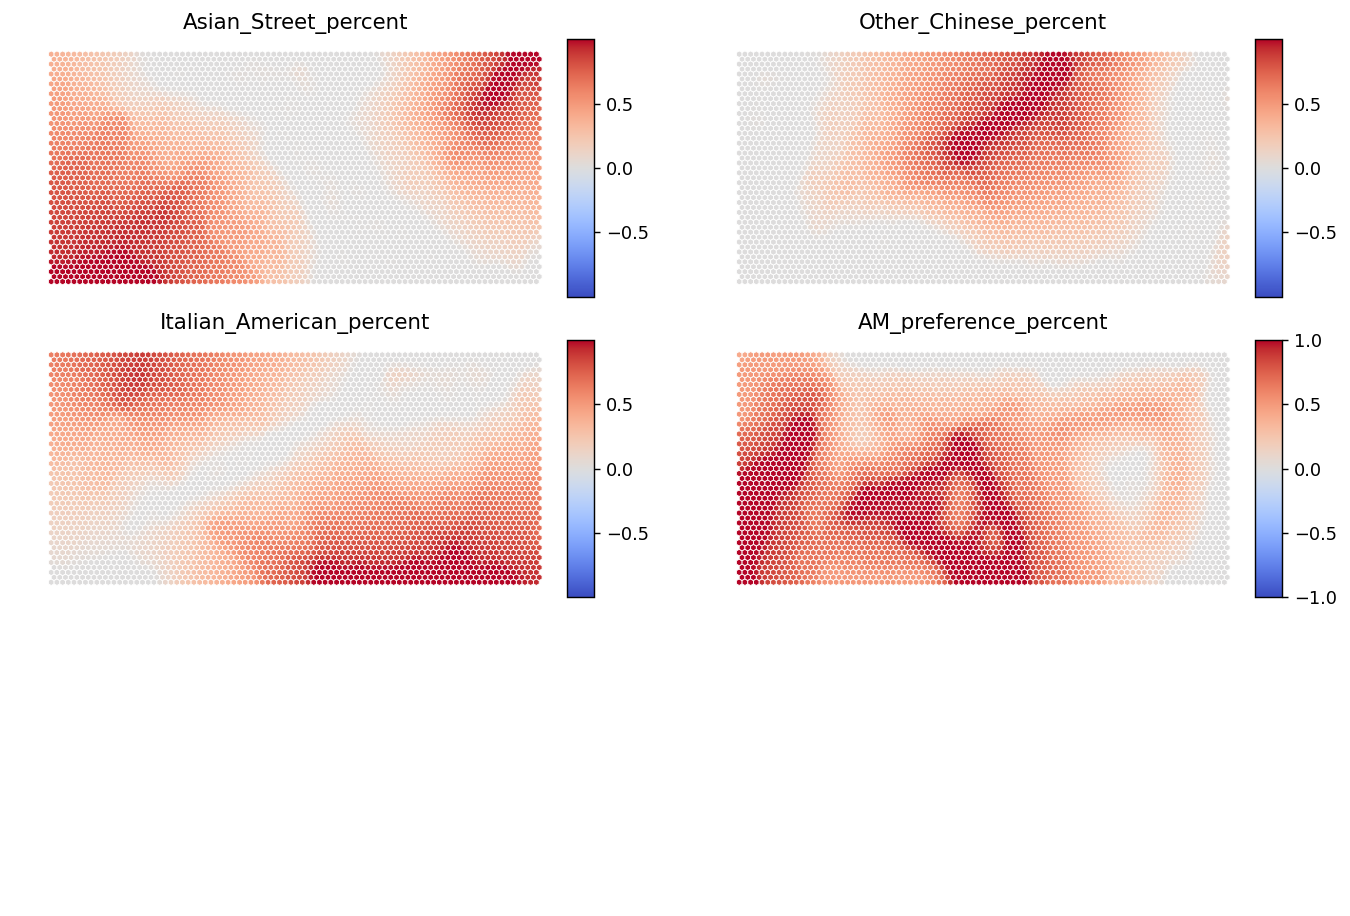

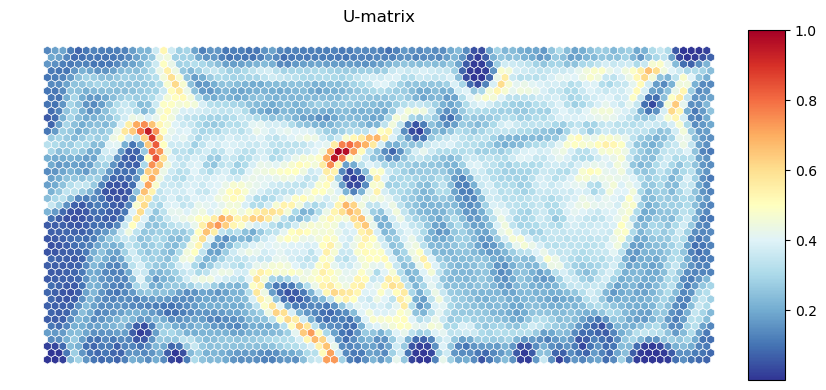

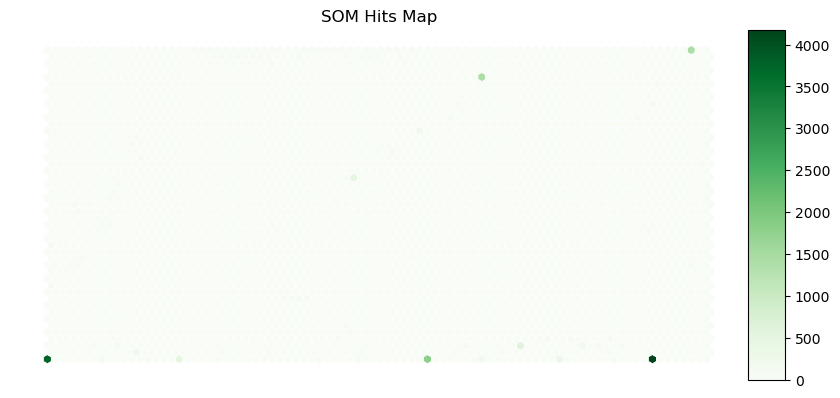

In [70]:

weights = sm.get_weights()
weights.shape
figsize=(10,7)
fig = plt.figure(figsize=figsize, constrained_layout=True, dpi=128, )
subfigs = fig.subfigures(3,2,wspace=.15)
colornorm = mpl_colors.Normalize(vmin=np.min(weights), vmax=np.max(weights))
for cpi, sf in zip(range(len(preferences_cols)), subfigs.flatten()):
    matrix_vals = weights[:,:,cpi]
    vext = np.max(np.abs([np.min(matrix_vals), np.max(matrix_vals)]))
    #colornorm = mpl_colors.Normalize(vmin=np.min(matrix_vals), vmax=np.max(matrix_vals))
    colornorm = mpl_colors.CenteredNorm(vcenter=0, halfrange=vext)
    sf = plot_hexagons(sm, sf, 
                    colornorm,
                    matrix_vals,
                    label=preferences_cols[cpi],
                    cmap=cm.coolwarm,
                    )
    
    
umatrix = sm.distance_map(scaling='mean')
fig = plt.figure(figsize=figsize)
colornorm = mpl_colors.Normalize(vmin=np.min(umatrix), vmax=np.max(umatrix))
fig = plot_hexagons(sm, fig, 
                    colornorm,
                    umatrix,
                    label="U-matrix",
                    cmap=cm.RdYlBu_r,
                    )


hitsmatrix = sm.activation_response(df[preferences_cols].values)
fig = plt.figure(figsize=figsize)
colornorm = mpl_colors.Normalize(vmin=0, vmax=np.max(hitsmatrix))
fig = plot_hexagons(sm, fig, 
                    colornorm,
                    hitsmatrix,
                    label="SOM Hits Map",
                    cmap=cm.Greens,
                    )

In [71]:
weights_flat = sm.get_weights().reshape((M*N),len(preferences_cols))
weights_flat.shape

(4042, 4)

## KMeans on SOM 

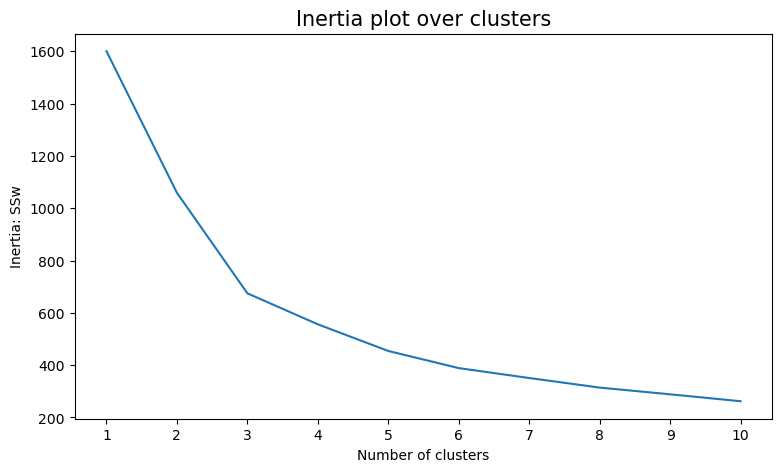

In [72]:


range_clusters = range(1, 11)
inertia = []
for n_clus in range_clusters:  
    kmclust = KMeans(n_clusters=n_clus, init='k-means++', n_init=15, random_state=42)
    kmclust.fit(weights_flat)
    inertia.append(kmclust.inertia_)
    
fig, ax = plt.subplots(figsize=(9,5))
ax.plot(range_clusters, inertia)
ax.set_xticks(range_clusters)
ax.set_ylabel("Inertia: SSw")
ax.set_xlabel("Number of clusters")
ax.set_title("Inertia plot over clusters", size=15)
plt.show()



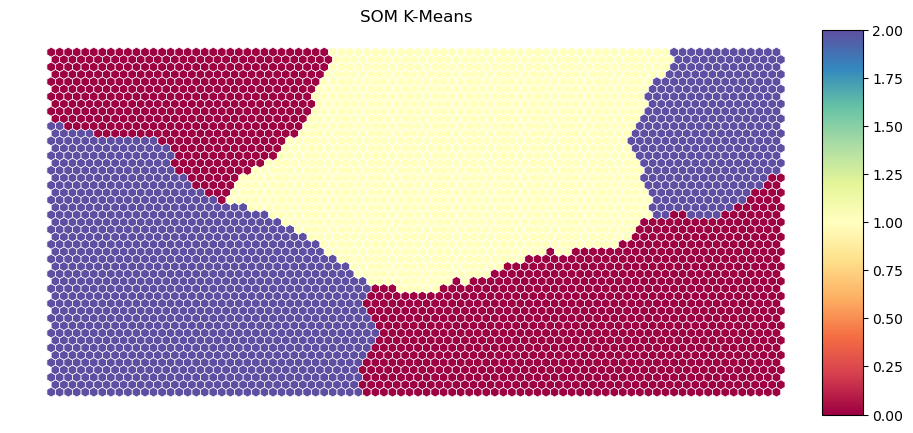

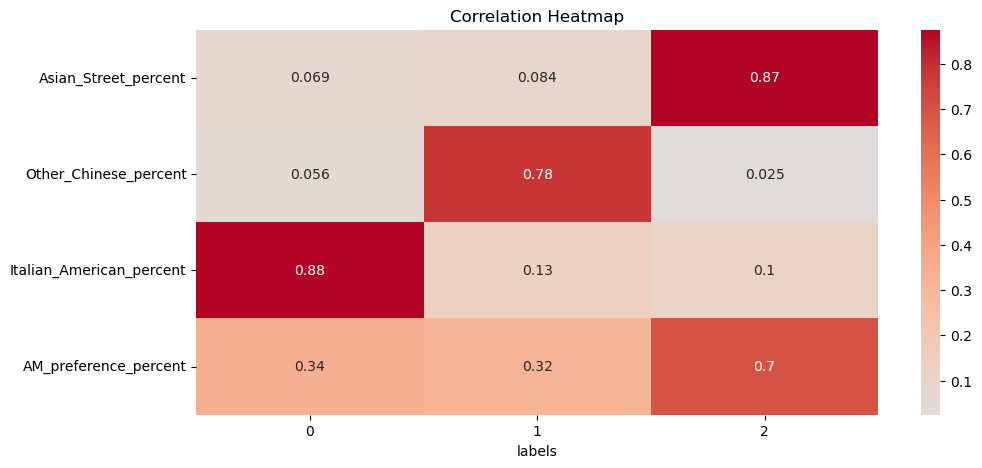

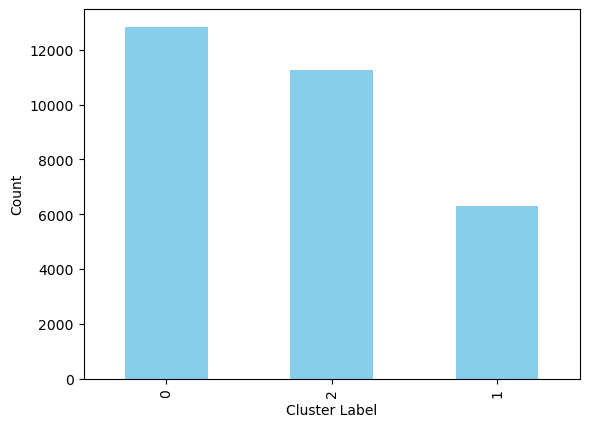

In [73]:


kmeans = KMeans(n_clusters=3, init='k-means++', n_init=20, random_state=42)

nodeclus_labels = kmeans.fit_predict(weights_flat)

kmeans_matrix = nodeclus_labels.reshape((M,N))

fig = plt.figure(figsize=(11,5))
colornorm = mpl_colors.Normalize(vmin=0, vmax=np.max(kmeans_matrix))
fig = plot_hexagons(sm, fig, 
                    colornorm,
                    kmeans_matrix,
                    label="SOM K-Means",
                    cmap=cm.Spectral,
                    )


nodes = weights_flat
df_nodes = pd.DataFrame(nodes, columns=preferences_cols)
df_nodes['label'] = nodeclus_labels

# shape df.shape[0], 2 dimension 
bmu_index = np.array([sm.winner(x) for x in df[preferences_cols].values])
som_final_labels = [kmeans_matrix[i[0]][i[1]] for i in bmu_index]

fig = plt.figure(figsize=(11,5))
df_concat = pd.concat((df[preferences_cols], pd.Series(som_final_labels, name='labels', index=df.index)), axis=1)
sns.heatmap(df_concat.groupby("labels").mean().T, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

df_concat['labels'].value_counts().plot(kind='bar', color='skyblue')
plt.xlabel('Cluster Label')
plt.ylabel('Count')
plt.show()


In [74]:

silh = silhouette_score(df[preferences_cols], som_final_labels, metric='cosine')
silhouettes_avgs.append(silh)
silh


0.7055043405467555

## Hierarchical on SOM 

C:\Users\gaspa\AppData\Local\Temp\ipykernel_30044\1934158007.py:15: UserWarning: The markers list has more values (4) than needed (2), which may not be intended.
  sns.lineplot(data=r2_hc_methods, linewidth=2.5, markers=["o"]*4)


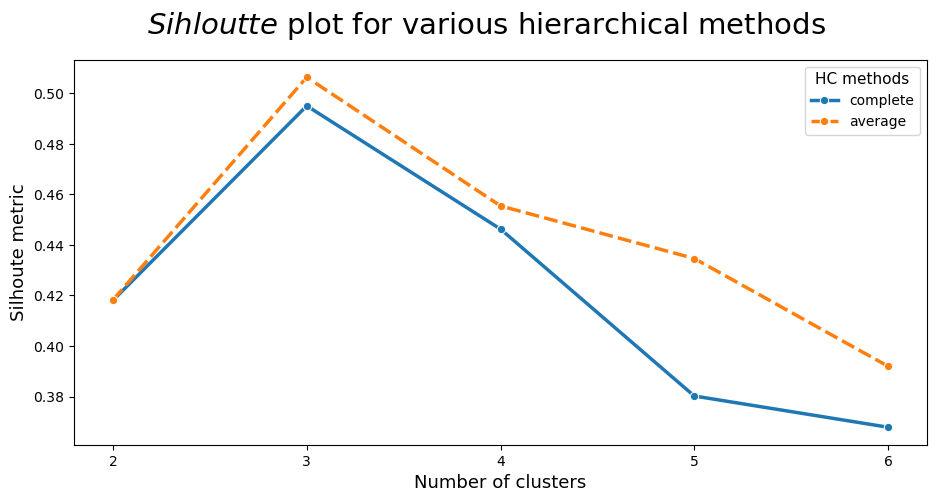

In [75]:

weights_flat = pd.DataFrame(weights_flat, columns=preferences_cols)


hc_methods = ["complete", "average"] # ward doesnt work with cosine distances / single always bad
max_nclus = 6
r2_hc = np.vstack([ get_silhouette_hc(weights_flat, 
                              link, 
                              max_nclus=max_nclus, 
                              min_nclus=2, 
                              dist="cosine") 
                              for link in hc_methods])

r2_hc_methods = pd.DataFrame(r2_hc.T, index=range(2, max_nclus + 1), columns=hc_methods)
fig = plt.figure(figsize=(11,5))
sns.lineplot(data=r2_hc_methods, linewidth=2.5, markers=["o"]*4)
plt.legend(title="HC methods", title_fontsize=11)
plt.xticks(range(2, max_nclus + 1))
plt.xlabel("Number of clusters", fontsize=13)
plt.ylabel("Silhoute metric", fontsize=13)
fig.suptitle("$Sihloutte$ plot for various hierarchical methods", fontsize=21)
plt.show()

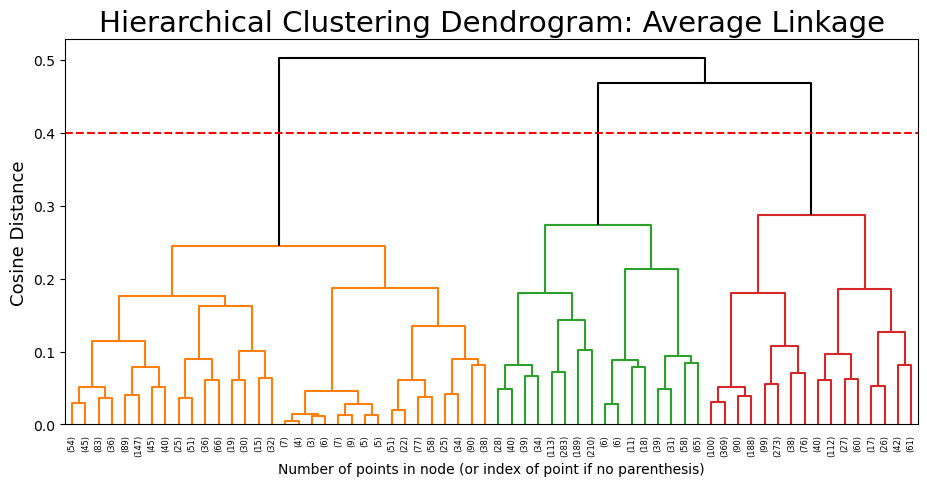

In [76]:

link = 'average'
distance = 'cosine'
hclust = AgglomerativeClustering(linkage=link, metric=distance, distance_threshold=0, n_clusters=None)

hclust.fit_predict(weights_flat)

counts = np.zeros(hclust.children_.shape[0])
n_samples = len(hclust.labels_)
for i, merge in enumerate(hclust.children_):
    current_count = 0
    for child_idx in merge:
        if child_idx < n_samples:
            current_count += 1 
        else:
            current_count += counts[child_idx - n_samples]
    counts[i] = current_count
linkage_matrix = np.column_stack([hclust.children_, hclust.distances_, counts]).astype(float)

fig = plt.figure(figsize=(11,5))
y_threshold = 0.4
dendrogram(linkage_matrix, truncate_mode='level', p=5, color_threshold=y_threshold, above_threshold_color='k')
plt.hlines(y_threshold, 0, 1000, colors="r", linestyles="dashed")
plt.title(f'Hierarchical Clustering Dendrogram: {link.title()} Linkage', fontsize=21)
plt.xlabel('Number of points in node (or index of point if no parenthesis)')
plt.ylabel(f'{distance.title()} Distance', fontsize=13)
plt.show()


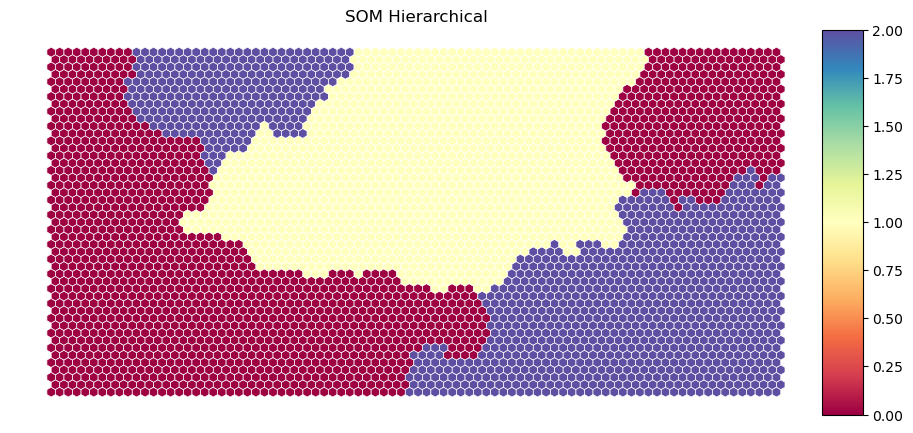

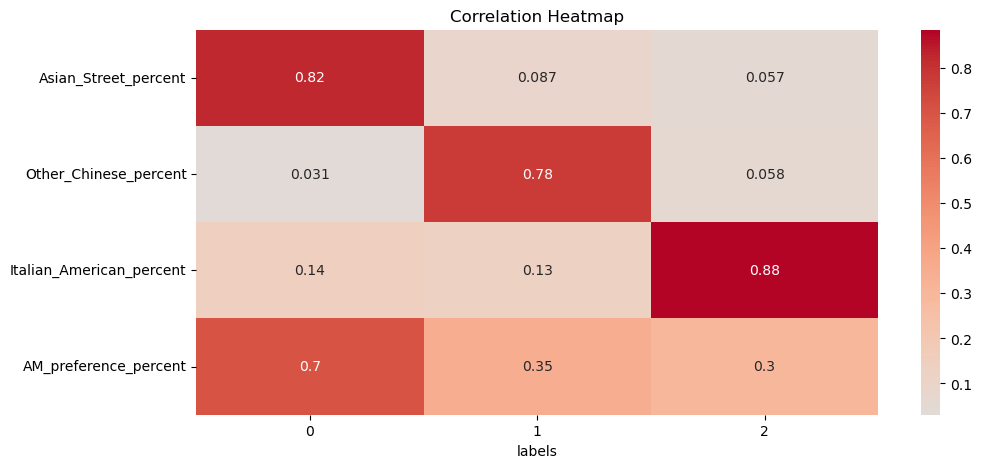

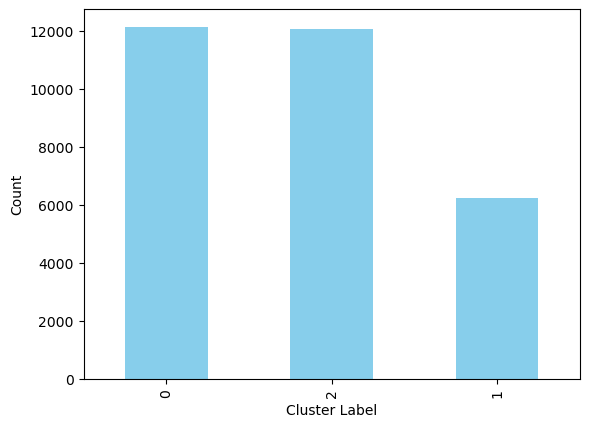

In [77]:

hc_clust = AgglomerativeClustering(n_clusters=3, linkage="average", metric="cosine")
nodeclus_labels = hc_clust.fit_predict(weights_flat)

hclust_matrix = nodeclus_labels.reshape((M,N))

fig = plt.figure(figsize=(11,5))
colornorm = mpl_colors.Normalize(vmin=0, vmax=np.max(hclust_matrix))
fig = plot_hexagons(sm, fig, 
                    colornorm,
                    hclust_matrix,
                    label="SOM Hierarchical",
                    cmap=cm.Spectral,
                    )



nodes = weights_flat
df_nodes = pd.DataFrame(nodes, columns=preferences_cols)
df_nodes['label'] = nodeclus_labels

bmu_index = np.array([sm.winner(x) for x in df[preferences_cols].values])

som_final_labels = [hclust_matrix[i[0]][i[1]] for i in bmu_index]

fig = plt.figure(figsize=(11,5))
df_concat = pd.concat((df[preferences_cols], pd.Series(som_final_labels, name='labels', index=df.index)), axis=1)
sns.heatmap(df_concat.groupby("labels").mean().T, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()


df_concat['labels'].value_counts().plot(kind='bar', color='skyblue')
plt.xlabel('Cluster Label')
plt.ylabel('Count')
plt.show()


In [78]:

silho = silhouette_score(df[preferences_cols], som_final_labels, metric='cosine')
silhouettes_avgs.append(silho)

silho

0.6656719267123375

# Gaussian Mixture Model

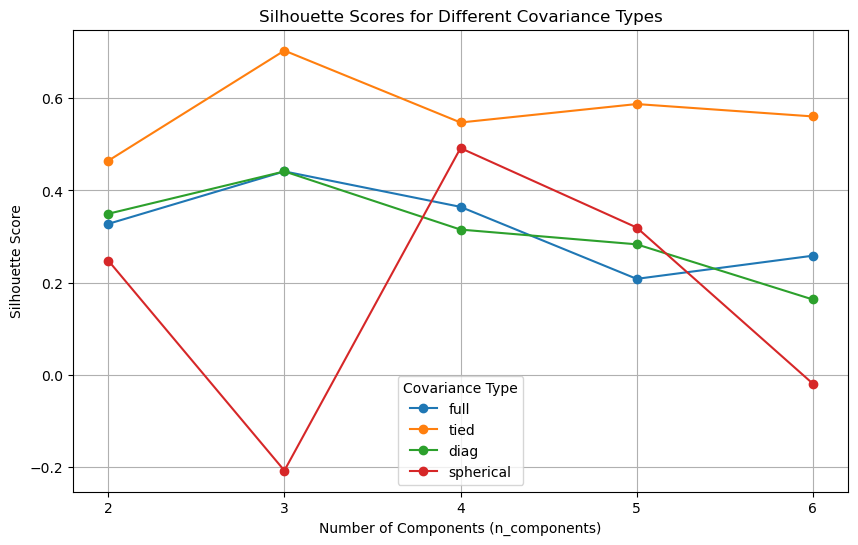

In [79]:

n_components = np.arange(2, 7)
cov_types = ['full', 'tied', 'diag', 'spherical']
scores = {}

for cova in cov_types:
    models = [GaussianMixture(n, covariance_type=cova, n_init=10, random_state=42).fit(df[preferences_cols]) 
              for n in n_components]
    
    scores[cova] = [silhouette_score(df[preferences_cols], model.predict(df[preferences_cols]), metric='cosine') 
                    for model in models]

plt.figure(figsize=(10, 6))
for cova in cov_types:
    plt.plot(n_components, scores[cova], marker='o', label=f'{cova}')
plt.title('Silhouette Scores for Different Covariance Types')
plt.xlabel('Number of Components (n_components)')
plt.ylabel('Silhouette Score')
plt.xticks(n_components)
plt.legend(title='Covariance Type')
plt.grid(True)
plt.show()


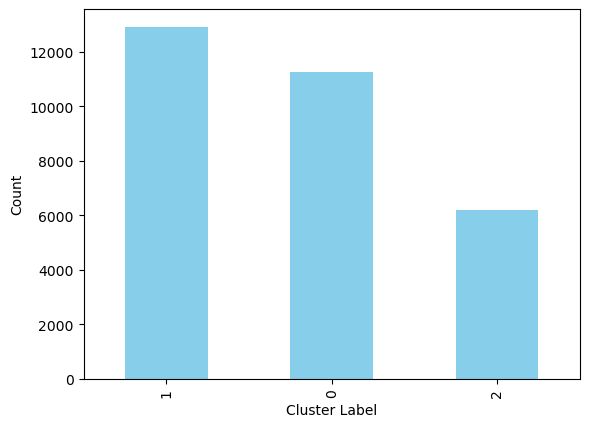

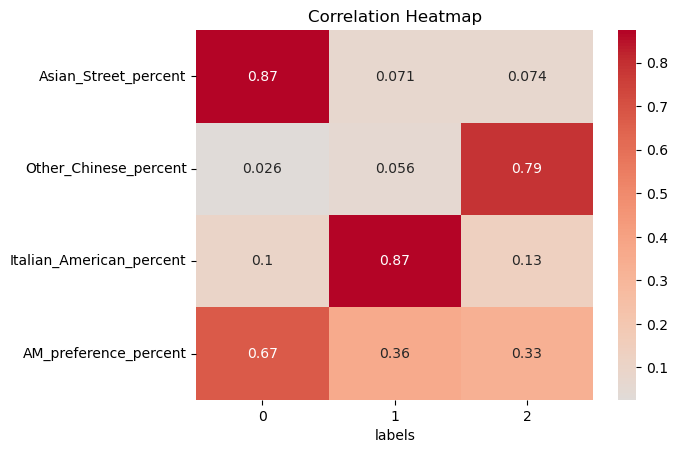

In [80]:

gm = GaussianMixture(n_components=3, covariance_type='tied', n_init=10, random_state=42)
gm_labels = gm.fit_predict(df[preferences_cols])

df_concat = pd.concat((df[preferences_cols], pd.Series(gm_labels, name='labels', index=df.index)), axis=1)

df_concat['labels'].value_counts().plot(kind='bar', color='skyblue')
plt.xlabel('Cluster Label')
plt.ylabel('Count')
plt.show()

sns.heatmap(df_concat.groupby("labels").mean().T, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()


In [81]:

silho = silhouette_score(df[preferences_cols], gm_labels, metric='cosine')
silhouettes_avgs.append(silho)
silho

0.7032295572321842

# Comparison of Clustering Methods for Preferences

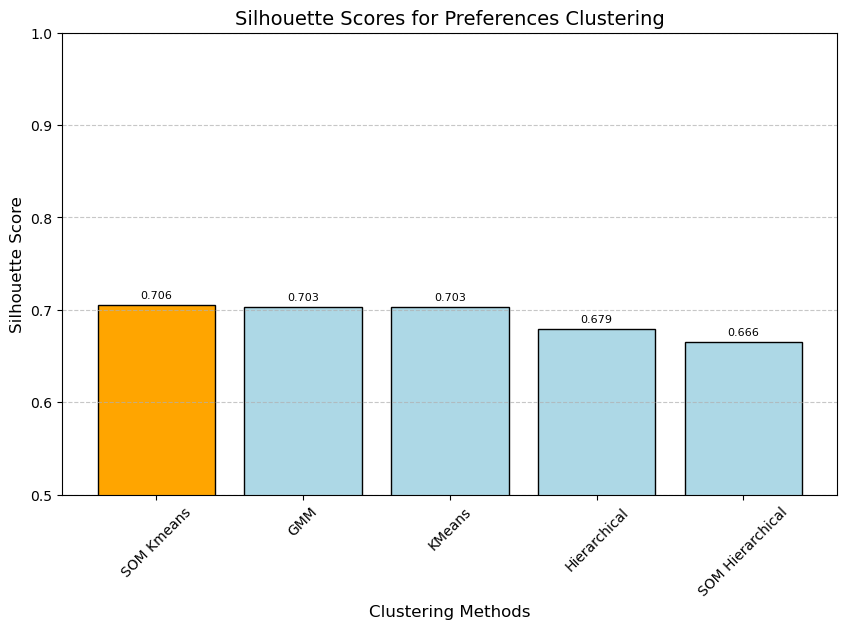

In [82]:

plt.figure(figsize=(10, 6))
methods = ['Hierarchical', 'KMeans', 'SOM Kmeans', "SOM Hierarchical", 'GMM']

sorted_indices = sorted(range(len(silhouettes_avgs)), key=lambda k: silhouettes_avgs[k], reverse=True)
methods = [methods[i] for i in sorted_indices]
silhouettes_avgs = [silhouettes_avgs[i] for i in sorted_indices]


bars = plt.bar(methods, silhouettes_avgs, color='lightblue', edgecolor='black')

max_index = silhouettes_avgs.index(max(silhouettes_avgs))
bars[max_index].set_color('orange')
bars[max_index].set_edgecolor('black')

for i, bar in enumerate(bars):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005, f'{silhouettes_avgs[i]:.3f}',
             ha='center', va='bottom', fontsize=8, color='black')

plt.title('Silhouette Scores for Preferences Clustering', fontsize=14)
plt.xlabel('Clustering Methods', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.ylim(0.5, 1)  
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.xticks(rotation=45) 
plt.show()

# Final Solution: Kmeans on SOM 

In [83]:

neigh = 'gaussian'
topol = 'hexagonal'
n_feats = len(preferences_cols)
activation_distc = 'cosine'

cov_matrix = np.cov(df[preferences_cols].T)
eigenvalues, _ = eig(cov_matrix)
eigenvalues = sorted(eigenvalues.round(3), reverse=True)
ratio = eigenvalues[0] / eigenvalues[1]
ratio.round(2)

grid_size = 4_000 
M = np.sqrt(grid_size * ratio).round().astype(int)
N = (grid_size / M).round().astype(int)


sm = MiniSom(M, N, n_feats, sigma=3, learning_rate=0.5, neighborhood_function=neigh, topology=topol, random_seed=42, activation_distance=activation_distc)

sm.random_weights_init(som_data)

print("Before training:")
print(f"QE: {sm.quantization_error(som_data).round(3)}")
print(f"TE: {sm.topographic_error(som_data).round(3)}")

sm.train_batch(som_data, 500_000)

print("After training:")
print(f"QE: {sm.quantization_error(som_data).round(3)}")
print(f"TE: {sm.topographic_error(som_data).round(3)}")


weights = sm.get_weights()



Before training:


c:\Users\gaspa\anaconda3\envs\DM2425\Lib\site-packages\minisom.py:631: RuntimeWarning: invalid value encountered in sqrt
  return sqrt(-2 * cross_term + input_data_sq + weights_flat_sq.T)


QE: 0.011
TE: 1.0
After training:
QE: 0.009
TE: 0.113


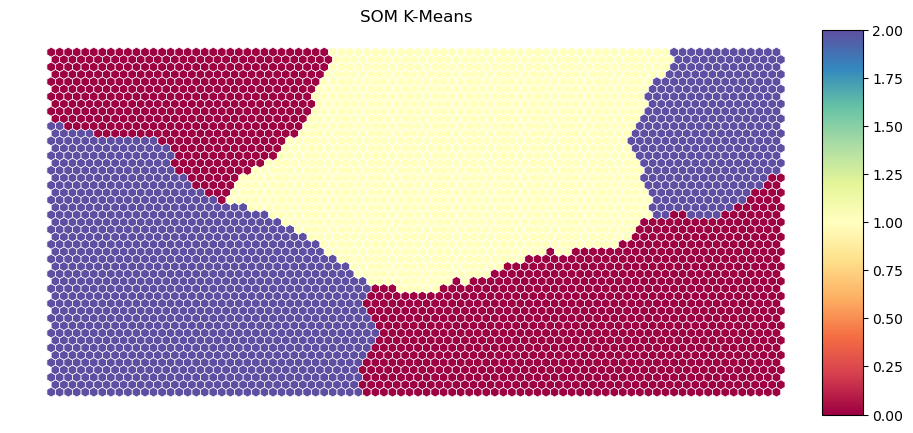

<Figure size 1100x500 with 0 Axes>

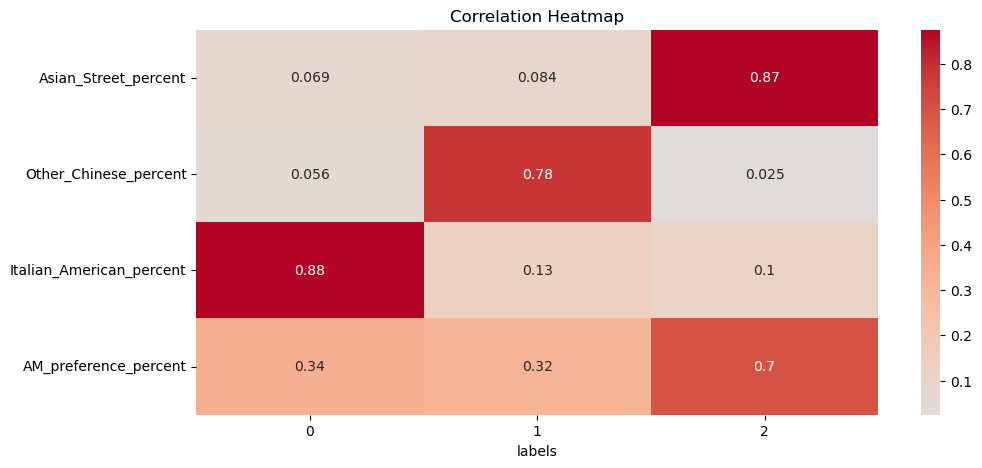

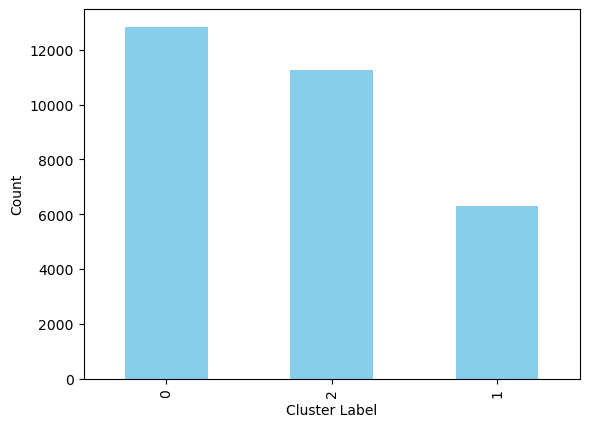

In [84]:

kmeans = KMeans(n_clusters=3, init='k-means++', n_init=20, random_state=42)

nodeclus_labels = kmeans.fit_predict(weights_flat)

kmeans_matrix = nodeclus_labels.reshape((M,N))

fig = plt.figure(figsize=(11,5))
colornorm = mpl_colors.Normalize(vmin=0, vmax=np.max(kmeans_matrix))
fig = plot_hexagons(sm, fig, 
                    colornorm,
                    kmeans_matrix,
                    label="SOM K-Means",
                    cmap=cm.Spectral,
                    )


nodes = weights_flat
df_nodes = pd.DataFrame(nodes, columns=preferences_cols)
df_nodes['label'] = nodeclus_labels

# shape df.shape[0], 2 dimension 
bmu_index = np.array([sm.winner(x) for x in df[preferences_cols].values])
som_final_labels = [kmeans_matrix[i[0]][i[1]] for i in bmu_index]

fig = plt.figure(figsize=(11,5))
df_concat = pd.concat((df[preferences_cols], pd.Series(som_final_labels, name='labels', index=df.index)), axis=1)
fig = plt.figure(figsize=(11,5))
sns.heatmap(df_concat.groupby("labels").mean().T, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

df_concat['labels'].value_counts().plot(kind='bar', color='skyblue')
plt.xlabel('Cluster Label')
plt.ylabel('Count')
plt.show()

In [85]:

silh = silhouette_score(df[preferences_cols], som_final_labels, metric='cosine', random_state=42)
silh

0.7055043405467555